In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Dataset for Data Analytics p2.xlsx")

# View first 5 rows
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Column info
df.info()

# Check missing values
df.isnull().sum()

Shape: (1200, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2),

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [4]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Remove duplicates (if any)
df.drop_duplicates(inplace=True)

# Check again
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [5]:
# Summary statistics
df.describe()

# Mean, Median, Count of TotalPrice
print("Mean:", df['TotalPrice'].mean())
print("Median:", df['TotalPrice'].median())
print("Count:", df['TotalPrice'].count())

Mean: 1053.9683
Median: 823.615
Count: 1200


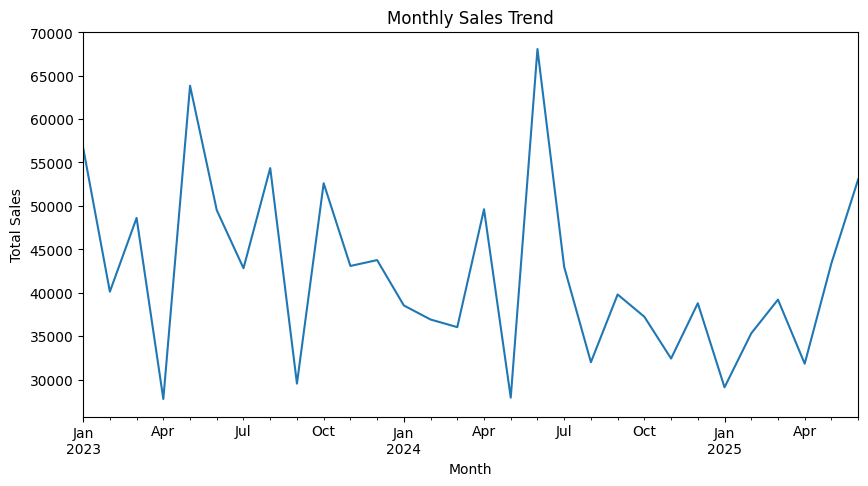

In [6]:
# Extract month
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(kind='line', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [11]:
# Clean column names
df.columns = df.columns.str.strip()

# Print columns to see actual names
print("Columns are:", list(df.columns))

# Try to find correct category column
# Replace 'Category' below with the correct name from output

category_col = 'Category'   # <-- CHANGE THIS after seeing print output

# Group and plot
category_sales = df.groupby(category_col)['TotalPrice'].sum()

category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Category")
plt.ylabel("Total Sales")
plt.xlabel(category_col)

plt.tight_layout()
plt.show()

Columns are: ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Month']


KeyError: 'Category'